In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


In [ ]:
df['FastingBS'].value_counts()

,count
FastingBS,
0,704
1,214


In [ ]:
num_cols = df.select_dtypes(include=np.number)
obj_cols = df.select_dtypes(include='object')


In [ ]:
num_cols.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for i in obj_cols.columns:
    df[i] = encoder.fit_transform(df[i])
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


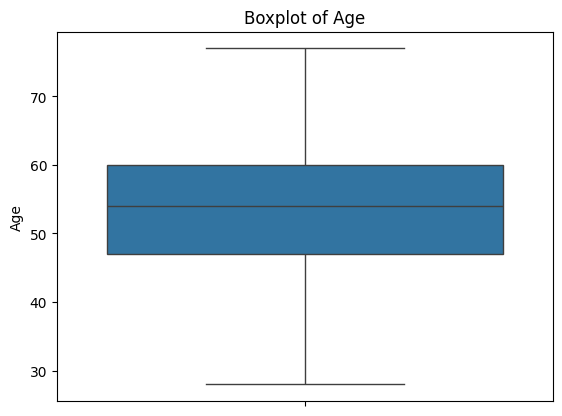

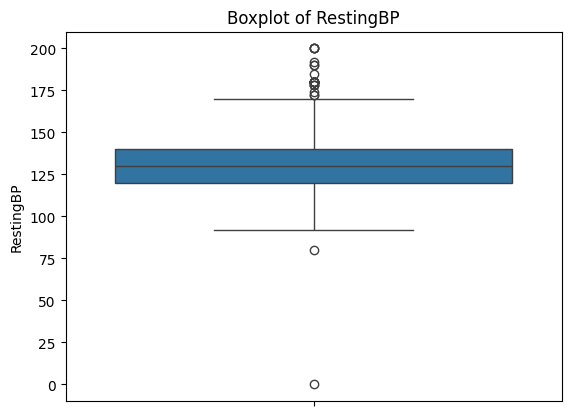

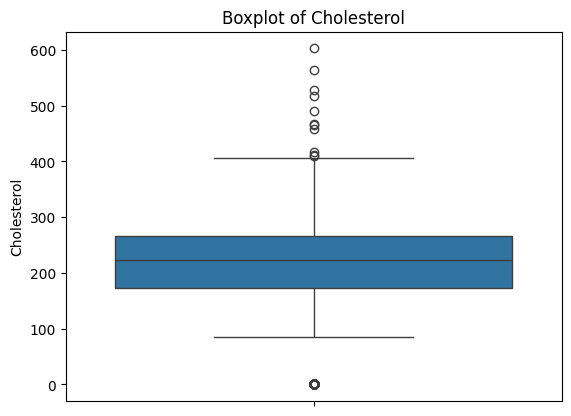

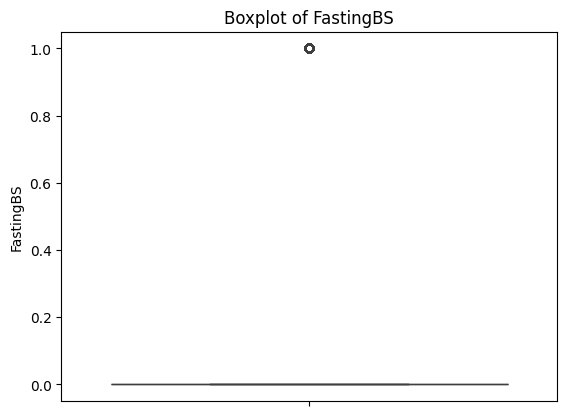

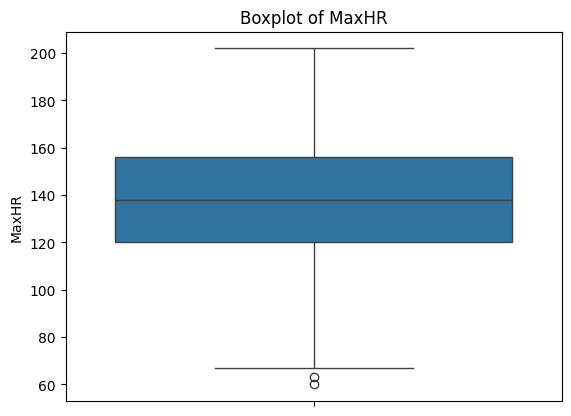

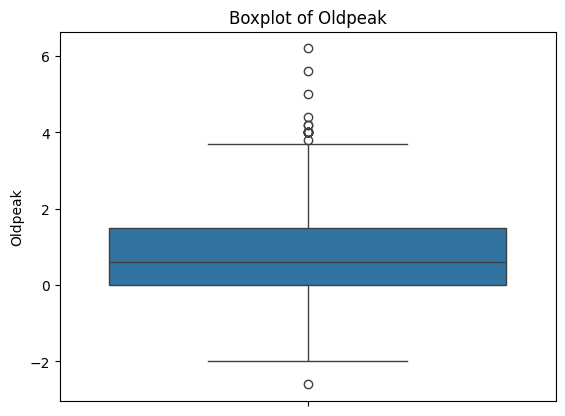

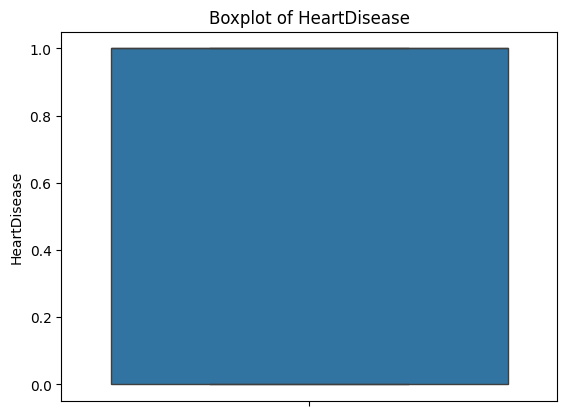

In [ ]:
for i in num_cols.columns:
    sns.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

In [ ]:
from scipy.stats import skew
for i in num_cols.columns:
    print(f"{i} : Skewness = {skew(df[i])}")

Age : Skewness = -0.19561273124487544
RestingBP : Skewness = 0.17954532149156327
Cholesterol : Skewness = -0.6090891046626045
FastingBS : Skewness = 1.2624170859488144
MaxHR : Skewness = -0.14412342991429325
Oldpeak : Skewness = 1.0211999031135828
HeartDisease : Skewness = -0.21473473034684154


In [ ]:
def replace_outliers(d):
    for i in d.columns:
        q1 = d[i].quantile(0.25)
        q3 = d[i].quantile(0.75)
        iqr = q3 - q1
        lw = q1 - 1.5 * iqr
        uw = q3 + 1.5 * iqr
        d[i] = d[i].apply(lambda x : min(max(x, lw), uw))
    return d

In [ ]:
df2 = replace_outliers(num_cols)

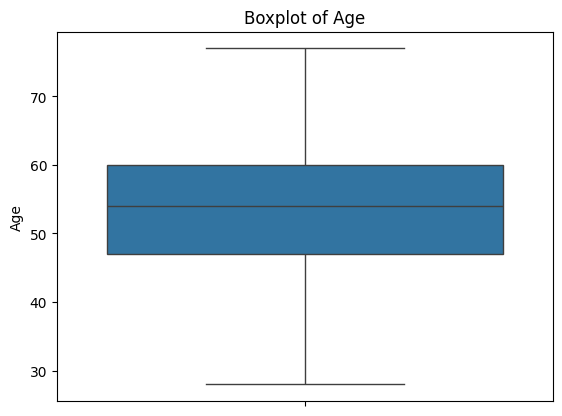

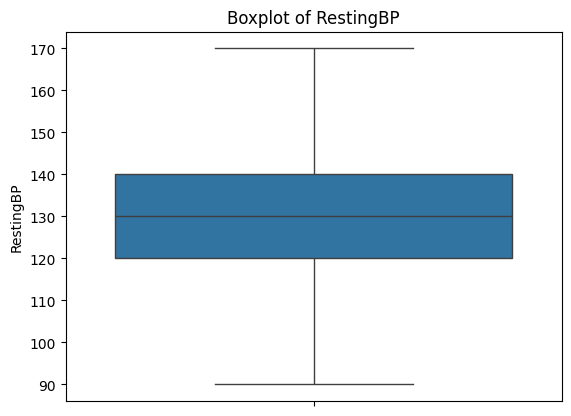

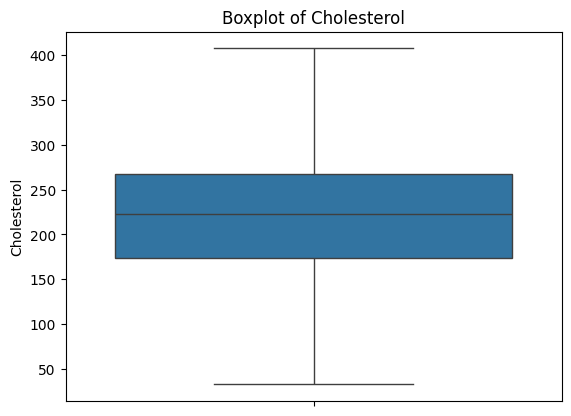

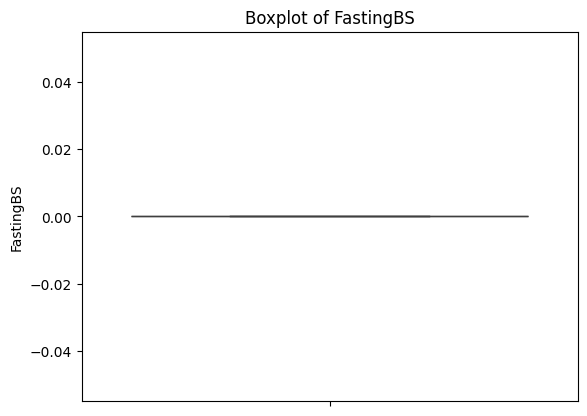

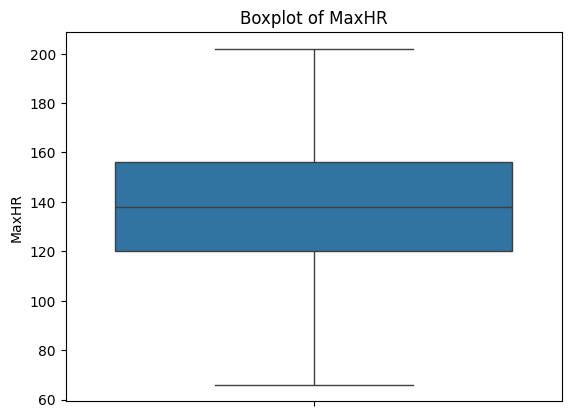

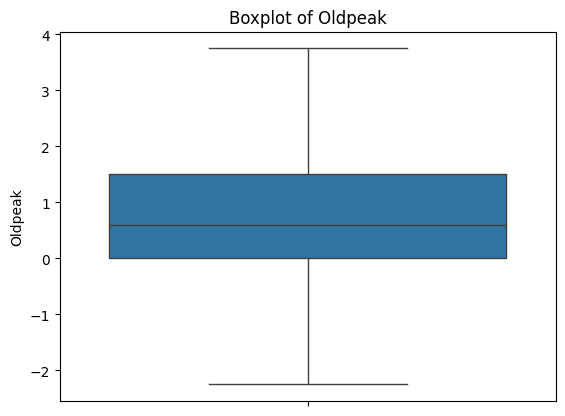

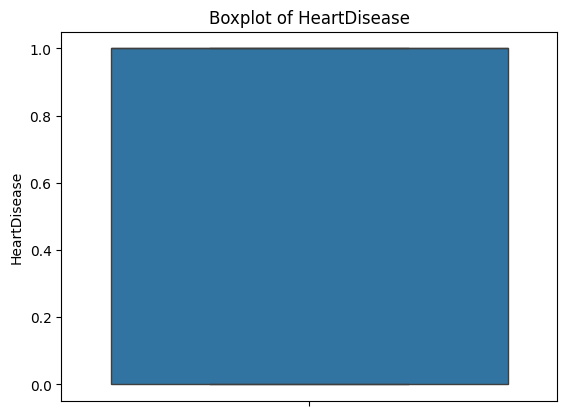

In [ ]:
for i in df2.columns:
    sns.boxplot(df2[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

In [ ]:
features = df.drop('HeartDisease', axis=1)
target = df['HeartDisease']

In [ ]:
features['Cholesterol'] = features['Cholesterol'].replace(0, np.nan)
features['Cholesterol'].fillna(features['Cholesterol'].median(), inplace=True)

In [ ]:
'''
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

continuous_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]
features[continuous_cols] = pt.fit_transform(features[continuous_cols])
'''

"\nfrom sklearn.preprocessing import PowerTransformer\n\npt = PowerTransformer(method='yeo-johnson')\n\ncontinuous_cols = [\n    'Age',\n    'RestingBP',\n    'Cholesterol',\n    'MaxHR',\n    'Oldpeak'\n]\nfeatures[continuous_cols] = pt.fit_transform(features[continuous_cols])\n"

In [ ]:
from scipy.stats import skew

for i in features.columns:
    print(f"{i} : Skewness = {skew(features[i])}")

Age : Skewness = -0.19561273124487544
Sex : Skewness = -1.4222108073311597
ChestPainType : Skewness = 0.7926178828866415
RestingBP : Skewness = 0.17954532149156327
Cholesterol : Skewness = 1.4446304394947997
FastingBS : Skewness = 1.2624170859488144
RestingECG : Skewness = 0.008478079453854552
MaxHR : Skewness = -0.14412342991429325
ExerciseAngina : Skewness = 0.3906897792046791
Oldpeak : Skewness = 1.0211999031135828
ST_Slope : Skewness = -0.380758306920403


In [ ]:
df['Sex'].value_counts()

,count
Sex,
1,725
0,193


In [ ]:
df['FastingBS'].value_counts()

,count
FastingBS,
0,704
1,214


In [ ]:
df['RestingECG'].value_counts()

,count
RestingECG,
1,552
0,188
2,178


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
def mymodel(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    labels = model.classes_
    # checking for overfit and underfit
    print(f'Training Score : {model.score(x_train, y_train)}')
    print(f'Testing Score : {model.score(x_test, y_test)}')
    # evaluation metrics
    c = pd.DataFrame(confusion_matrix(y_test, y_pred),
                     index = labels,
                     columns = labels)
    print(f'Confusion Matrix : \n{c}')
    print(f'Classification Report : \n{classification_report(y_test, y_pred)}')
    return model

In [ ]:
dt = mymodel(DecisionTreeClassifier())

Training Score : 1.0
Testing Score : 0.7869565217391304
Confusion Matrix : 
    0    1
0  76   13
1  36  105
Classification Report : 
              precision    recall  f1-score   support

           0       0.68      0.85      0.76        89
           1       0.89      0.74      0.81       141

    accuracy                           0.79       230
   macro avg       0.78      0.80      0.78       230
weighted avg       0.81      0.79      0.79       230



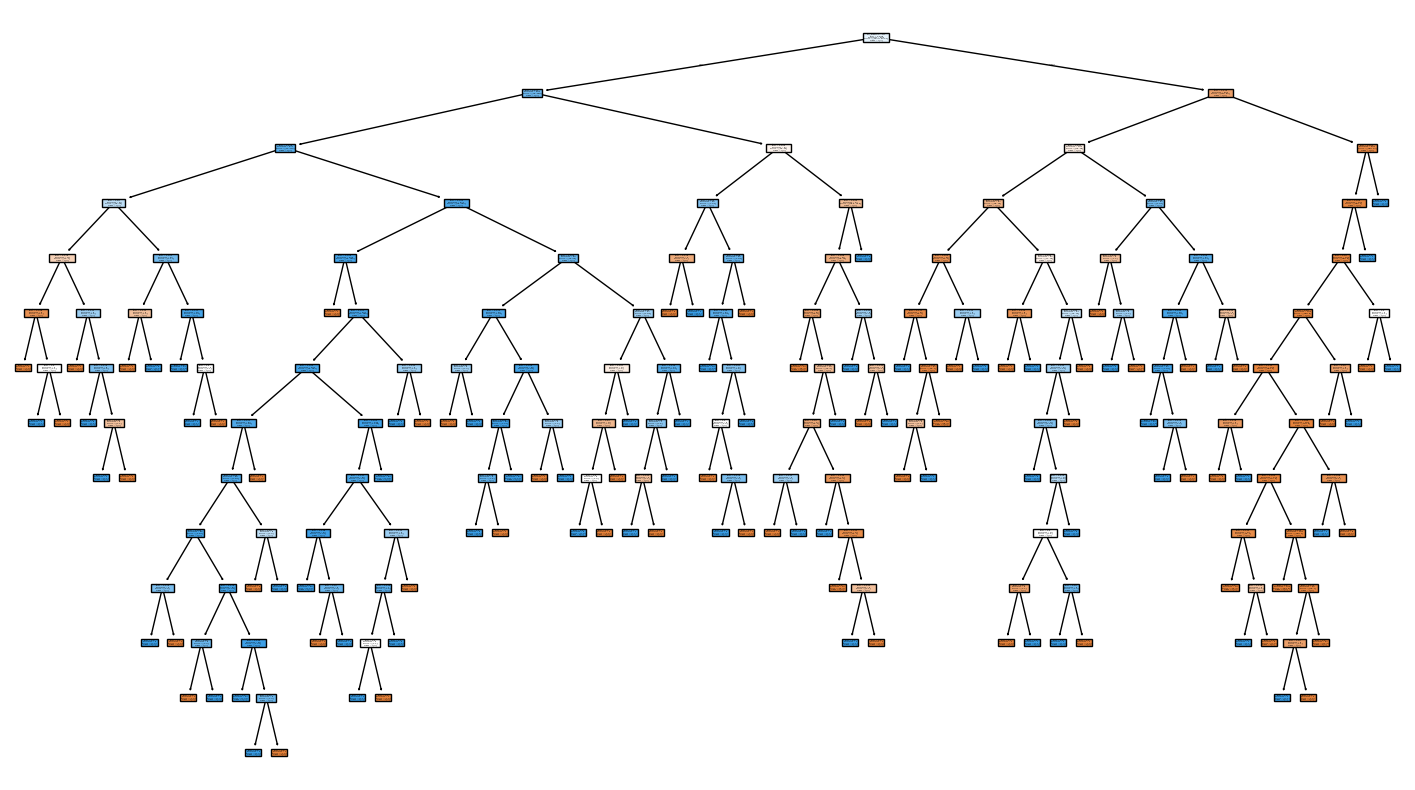

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
tree.plot_tree(
    dt,
    feature_names=x_train.columns,
    class_names=True,
    filled=True
)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
model_r = mymodel(rf)

Training Score : 1.0
Testing Score : 0.8565217391304348
Confusion Matrix : 
    0    1
0  76   13
1  20  121
Classification Report : 
              precision    recall  f1-score   support

           0       0.79      0.85      0.82        89
           1       0.90      0.86      0.88       141

    accuracy                           0.86       230
   macro avg       0.85      0.86      0.85       230
weighted avg       0.86      0.86      0.86       230



In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
model_l = mymodel(lr)

Training Score : 0.8386627906976745
Testing Score : 0.8826086956521739
Confusion Matrix : 
    0    1
0  78   11
1  16  125
Classification Report : 
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        89
           1       0.92      0.89      0.90       141

    accuracy                           0.88       230
   macro avg       0.87      0.88      0.88       230
weighted avg       0.88      0.88      0.88       230



In [ ]:
final_model = model_r


In [ ]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)